### visualize cumulative recall curve with transfomers 

In [1]:
# ==============================
# Notebook: Recall@k Curves for N-gram Baselines
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from typing import Dict, List, Tuple

# ------------------------------
# 0) Config
# ------------------------------
DATA_PATH = "processed_data/clusters/screen_clusters_k40.tsv"  # <-- change this
K_LIST = [1, 3, 5, 10,20]
ALPHA_SMOOTH = 1.0
LAMBDA_BACKOFF = 0.2

# If your clusters in the TSV are not 0..K-1 contiguous, we will remap them.
# ------------------------------
# 1) Load traces from TSV
# ------------------------------
def load_traces_tsv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    # Expected columns:
    # screen_key, app_id, trace_id, screen_id, cluster_id
    needed = {"app_id", "trace_id", "cluster_id"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in TSV: {missing}. Found: {list(df.columns)}")
    return df

df = load_traces_tsv(DATA_PATH)
df.head()

# ------------------------------
# 2) Build traces per (app_id, trace_id)
# ------------------------------
def build_traces(df: pd.DataFrame, collapse_consecutive_duplicates: bool = True):
    """
    Returns list of tuples: (app_id, trace_id, seq_of_cluster_ids)
    """
    traces = []
    grouped = df.groupby(["app_id", "trace_id"], sort=False)

    for (app_id, trace_id), g in grouped:
        # Preserve original order as in file; if you have a time/order column, sort by it here
        seq = g["cluster_id"].tolist()

        if collapse_consecutive_duplicates and len(seq) > 1:
            collapsed = [seq[0]]
            for x in seq[1:]:
                if x != collapsed[-1]:
                    collapsed.append(x)
            seq = collapsed

        if len(seq) >= 2:
            traces.append((app_id, trace_id, seq))

    return traces

traces_raw = build_traces(df, collapse_consecutive_duplicates=True)
print("Num traces (len>=2):", len(traces_raw))

# ------------------------------
# 3) Remap cluster IDs to 0..K-1 contiguous
# ------------------------------
def remap_clusters(traces):
    all_ids = []
    for _, _, seq in traces:
        all_ids.extend(seq)
    uniq = sorted(set(all_ids))
    id2new = {old:i for i, old in enumerate(uniq)}
    new2old = {i:old for old, i in id2new.items()}

    remapped = []
    for app_id, trace_id, seq in traces:
        remapped.append((app_id, trace_id, [id2new[x] for x in seq]))

    return remapped, id2new, new2old, len(uniq)

traces, id2new, new2old, K = remap_clusters(traces_raw)
print("K (unique clusters observed):", K)

# ------------------------------
# 4) App-split train/test
# ------------------------------
def app_split(traces, test_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    apps = sorted(set(a for a, _, _ in traces))
    rng.shuffle(apps)
    n_test = int(round(len(apps) * test_frac))
    test_apps = set(apps[:n_test])

    train = [t for t in traces if t[0] not in test_apps]
    test  = [t for t in traces if t[0] in test_apps]
    return train, test, test_apps

train_traces, test_traces, test_apps = app_split(traces, test_frac=0.2, seed=42)
print("Train traces:", len(train_traces))
print("Test traces :", len(test_traces))
print("Test apps   :", len(test_apps))

# ------------------------------
# 5) Training: Unigram / Bigram / Trigram (counts)
# ------------------------------
def train_unigram_next(train_traces, K: int, alpha: float = 1.0):
    counts = np.zeros(K, dtype=np.float64)
    for _, _, seq in train_traces:
        for b in seq[1:]:
            counts[b] += 1.0
    counts += alpha
    probs = counts / counts.sum()
    return probs  # shape [K]

def train_bigram_counts(train_traces, K: int, alpha: float = 1.0):
    # counts[a][b] transitions
    counts = np.zeros((K, K), dtype=np.float64)
    for _, _, seq in train_traces:
        for a, b in zip(seq[:-1], seq[1:]):
            counts[a, b] += 1.0
    counts += alpha
    # normalize rows
    probs = counts / counts.sum(axis=1, keepdims=True)
    return probs  # shape [K,K]

def train_trigram_counts(train_traces, K: int, alpha: float = 1.0):
    # counts[(a,b)][c]
    counts = defaultdict(lambda: np.zeros(K, dtype=np.float64))
    for _, _, seq in train_traces:
        if len(seq) < 3:
            continue
        for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
            counts[(a, b)][c] += 1.0

    # apply smoothing to each context that exists
    trigram_probs = {}
    for ctx, vec in counts.items():
        vec = vec + alpha
        trigram_probs[ctx] = vec / vec.sum()
    return trigram_probs  # dict[(a,b)] -> np.array[K]

unigram_probs = train_unigram_next(train_traces, K, alpha=ALPHA_SMOOTH)
bigram_probs  = train_bigram_counts(train_traces, K, alpha=ALPHA_SMOOTH)
trigram_probs = train_trigram_counts(train_traces, K, alpha=ALPHA_SMOOTH)

print("Trigram contexts:", len(trigram_probs))

# ------------------------------
# 6) Backoff scoring for trigram: P(c | a,b) with lambda
#    If trigram context missing -> fallback to bigram row.
#    Use bigram + unigram mixture.
# ------------------------------
def score_next_probs(history_a, history_b, trigram_probs, bigram_probs, unigram_probs,
                     lambda_backoff=0.2):
    """
    Returns probability vector over next cluster, shape [K]
    """
    if (history_a, history_b) in trigram_probs:
        p_tri = trigram_probs[(history_a, history_b)]
        # mix with bigram as extra robustness (optional)
        p_bi = bigram_probs[history_b]
        p = (1 - lambda_backoff) * p_tri + lambda_backoff * p_bi
        return p
    else:
        # no trigram context => bigram + unigram backoff
        p_bi = bigram_probs[history_b]
        p = (1 - lambda_backoff) * p_bi + lambda_backoff * unigram_probs
        return p

# ------------------------------
# 7) Eval: Recall@k (trigram-subset positions only)
# ------------------------------
def eval_recall_at_k_unigram(test_traces, unigram_probs, k_list=(1,3,5,10), trigram_subset=True):
    ranked = np.argsort(-unigram_probs)
    hits = {k: 0 for k in k_list}
    total = 0

    for _, _, seq in test_traces:
        # trigram_subset means only evaluate t>=3 positions (need 2-history),
        # but unigram does not use history; we still align evaluation positions
        start = 2 if trigram_subset else 1
        for t in range(start, len(seq)):
            true_next = seq[t]
            total += 1
            for k in k_list:
                if true_next in ranked[:k]:
                    hits[k] += 1

    recall = {k: (hits[k] / total if total > 0 else 0.0) for k in k_list}
    return recall, total

def eval_recall_at_k_bigram(test_traces, bigram_probs, k_list=(1,3,5,10), trigram_subset=True):
    hits = {k: 0 for k in k_list}
    total = 0

    start = 2 if trigram_subset else 1
    for _, _, seq in test_traces:
        for t in range(start, len(seq)):
            prev = seq[t-1]
            true_next = seq[t]
            probs = bigram_probs[prev]
            ranked = np.argsort(-probs)
            total += 1
            for k in k_list:
                if true_next in ranked[:k]:
                    hits[k] += 1

    recall = {k: (hits[k] / total if total > 0 else 0.0) for k in k_list}
    return recall, total

def eval_recall_at_k_trigram(test_traces, trigram_probs, bigram_probs, unigram_probs,
                            lambda_backoff=0.2, k_list=(1,3,5,10)):
    hits = {k: 0 for k in k_list}
    total = 0

    for _, _, seq in test_traces:
        if len(seq) < 3:
            continue
        for t in range(2, len(seq)):
            a = seq[t-2]
            b = seq[t-1]
            true_next = seq[t]
            probs = score_next_probs(a, b, trigram_probs, bigram_probs, unigram_probs,
                                     lambda_backoff=lambda_backoff)
            ranked = np.argsort(-probs)
            total += 1
            for k in k_list:
                if true_next in ranked[:k]:
                    hits[k] += 1

    recall = {k: (hits[k] / total if total > 0 else 0.0) for k in k_list}
    return recall, total




Num traces (len>=2): 8005
K (unique clusters observed): 40
Train traces: 6397
Test traces : 1608
Test apps   : 1489
Trigram contexts: 1332


In [5]:

import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Dict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# -----------------------------
# Model: small causal Transformer
# -----------------------------
class CausalTransformer(nn.Module):
    def __init__(self, vocab_size: int, max_ctx: int, d_model=256, nhead=4, num_layers=4, dropout=0.1, pad_id=0):
        super().__init__()
        self.max_ctx = max_ctx
        self.pad_id = pad_id

        self.tok = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = nn.Embedding(max_ctx, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x, attn_mask):
        # x: (B,T), attn_mask: (B,T) True for real tokens
        B, T = x.shape
        pos_ids = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)

        h = self.tok(x) + self.pos(pos_ids)

        # zero padded positions (stability on some CUDA paths)
        h = h.masked_fill(~attn_mask.unsqueeze(-1), 0.0)

        # boolean causal mask: True means blocked
        causal = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)

        # padding mask: True means ignore key
        key_pad = ~attn_mask

        h = self.enc(h, mask=causal, src_key_padding_mask=key_pad)

        # re-zero padded outputs
        h = h.masked_fill(~attn_mask.unsqueeze(-1), 0.0)

        lengths = attn_mask.long().sum(dim=1)
        if (lengths <= 0).any():
            raise RuntimeError("Empty (all-pad) sequence encountered.")
        last_idx = lengths - 1

        last_h = h[torch.arange(B, device=x.device), last_idx]
        logits = self.head(last_h)
        return logits



In [11]:
import torch
import numpy as np

@torch.no_grad()
def eval_recall_at_k_transformer(
    test_traces,
    checkpoint_path,
    device="cuda",
    k_list=(1, 3, 5, 10),
    trigram_subset=True,
):
    """
    Transformer evaluation that matches the trigram/bigram evaluators style.

    Args:
        test_traces: list of (app_id, trace_id, seq_of_cluster_ids)
        checkpoint_path: path to .pt checkpoint saved by transformer training
        device: "cuda" or "cpu"
        k_list: tuple of k values (1,3,5,10)
        trigram_subset:
            - True: evaluate only positions where history exists (t>=2),
                    i.e., matched-context subset used by trigram.
            - False: evaluate on all bigram edges (t>=1).

    Returns:
        recall: dict {k: recall@k}
        total: number of evaluated edges
    """
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    # --- read checkpoint metadata ---
    K = int(ckpt["K"])
    pad_id = int(ckpt["pad_id"])
    bos_id = int(ckpt["bos_id"])
    cfg = ckpt.get("cfg", {})
    max_ctx = int(cfg.get("max_ctx", 16))

    # model hyperparams: must match training
    # if you saved these in cfg, use them; otherwise set defaults used in training
    d_model = int(cfg.get("d_model", 256))
    nhead = int(cfg.get("nhead", 4))
    num_layers = int(cfg.get("num_layers", 4))
    dropout = float(cfg.get("dropout", 0.1))

    vocab = K + 2

    # --- rebuild model + load weights ---
    model = CausalTransformer(
        vocab_size=vocab,
        max_ctx=max_ctx,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dropout=dropout,
        pad_id=pad_id,
    ).to(device)

    model.load_state_dict(ckpt["state_dict"], strict=True)
    model.eval()

    hits = {k: 0 for k in k_list}
    total = 0

    # if trigram_subset=True, require TWO REAL previous clusters.
    # - with BOS at index 0, the first position that has two real predecessors is t=3.
    start_t = 3 if trigram_subset else 1

    for _, _, seq in test_traces:

         # original seq is only real clusters
        if trigram_subset and len(seq) < 3:
            continue

        # prepend BOS (same training setup)
        seq = [bos_id] + list(seq)


        for t in range(start_t, len(seq)):
            prefix = seq[:t]
            true_next = seq[t]

            # build single-item batch with RIGHT padding
            T = min(max_ctx, len(prefix))
            x = torch.full((1, T), pad_id, dtype=torch.long, device=device)
            attn = torch.zeros((1, T), dtype=torch.bool, device=device)

            p = prefix[-T:]
            L = len(p)
            # RIGHT padding
            x[0, :L] = torch.tensor(p, dtype=torch.long, device=device)
            attn[0, :L] = True

            logits = model(x, attn)          # (1, vocab)
            logits = logits[0, :K]           # only real clusters [0..K-1]
            ranked = torch.argsort(logits, descending=True).detach().cpu().numpy()

            total += 1
            for k in k_list:
                if true_next in ranked[:k]:
                    hits[k] += 1

    recall = {k: (hits[k] / total if total > 0 else 0.0) for k in k_list}
    return recall, total


In [3]:
rec_u, tot_u = eval_recall_at_k_unigram(test_traces, unigram_probs, K_LIST, trigram_subset=True)
rec_b, tot_b = eval_recall_at_k_bigram(test_traces, bigram_probs, K_LIST, trigram_subset=True)
rec_t, tot_t = eval_recall_at_k_trigram(test_traces, trigram_probs, bigram_probs, unigram_probs,
                                        lambda_backoff=LAMBDA_BACKOFF, k_list=K_LIST)

print("Edges evaluated (unigram):", tot_u)
print("Edges evaluated (bigram) :", tot_b)
print("Edges evaluated (trigram):", tot_t)

print("Unigram Recall@k:", rec_u)
print("Bigram  Recall@k:", rec_b)
print("Trigram Recall@k:", rec_t)

Edges evaluated (unigram): 6058
Edges evaluated (bigram) : 6058
Edges evaluated (trigram): 6058
Unigram Recall@k: {1: 0.060911191812479365, 3: 0.15912842522284582, 5: 0.24694618686034994, 10: 0.4517992736876857, 20: 0.7256520303730604}
Bigram  Recall@k: {1: 0.12198745460548036, 3: 0.2692307692307692, 5: 0.38478045559590623, 10: 0.5747771541762958, 20: 0.8172664245625619}
Trigram Recall@k: {1: 0.21492241663915485, 3: 0.3626609442060086, 5: 0.463519313304721, 10: 0.6310663585341697, 20: 0.8367448002641136}


In [12]:
rec_tf, tot_tf = eval_recall_at_k_transformer(
    test_traces,
    checkpoint_path="experiments_weights/best_val_0.7187_transformer_next_cluster_16_200_0.2_8_0.3_256_3e-05_0.1_0.0.pt",
    device="cuda",
    k_list=K_LIST,
    trigram_subset=True
)

print("Edges evaluated (transformer):", tot_tf)
print("Transformer Recall@k:", rec_tf)

C:\Users\atsumilab\AppData\Local\Temp\ipykernel_56912\761414267.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location="cpu")


Edges evaluated (transformer): 6058
Transformer Recall@k: {1: 0.25982172334103665, 3: 0.4579068999669858, 5: 0.5643776824034334, 10: 0.7268075272367118, 20: 0.8951799273687686}


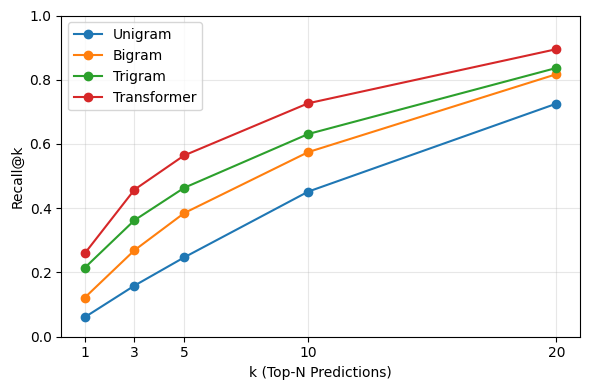

Saved figure: recall_at20_k40_curve_all.png


In [14]:
# ------------------------------
# 8) Plot cumulative Recall@k curves
# ------------------------------
results = {
    "Unigram": rec_u,
    "Bigram":  rec_b,
    "Trigram": rec_t,
    "Transformer": rec_tf,
}

plt.figure(figsize=(6,4))
for name, rec in results.items():
    y = [rec[k] for k in K_LIST]
    plt.plot(K_LIST, y, marker="o", label=name)

plt.xlabel("k (Top-N Predictions)")
plt.ylabel("Recall@k")
plt.xticks(K_LIST)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = "recall_at20_k40_curve_all.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved figure:", out_path)

--------

#### PR + AR + AUROC for Transformer

In [15]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

@torch.no_grad()
def collect_pos_neg_scores_transformer(
    model,
    test_traces,
    device,
    max_ctx,
    pad_id,
    bos_id,
    K,
    trigram_subset=True,
    num_neg=10,
    seed=42,
):
    """
    Build labels/scores for atypical-transition detection.

    For each prefix, we compute p(candidate | prefix) for:
      - the true next (label=1)
      - num_neg corrupted next clusters (label=0)
    """
    rng = np.random.default_rng(seed)
    model.eval()

    y_true = []
    y_score = []

    for _, _, seq in test_traces:
        seq2 = [bos_id] + list(seq)

        start_t = 3 if trigram_subset else 1
        if len(seq2) <= start_t:
            continue

        for t in range(start_t, len(seq2)):
            prefix = seq2[:t]
            true_next = seq2[t]

            T = min(max_ctx, len(prefix))
            x = torch.full((1, T), pad_id, dtype=torch.long, device=device)
            attn = torch.zeros((1, T), dtype=torch.bool, device=device)

            p = prefix[-T:]
            L = len(p)
            x[0, :L] = torch.tensor(p, dtype=torch.long, device=device)
            attn[0, :L] = True

            logits = model(x, attn)[0]          # (V,)
            probs = torch.softmax(logits, dim=0).detach().cpu().numpy()

            # Positive
            y_true.append(1)
            y_score.append(float(probs[true_next]))

            # Negatives (corrupt next)
            # sample from [0..K-1] only (exclude pad/bos)
            negs = []
            while len(negs) < num_neg:
                c = int(rng.integers(0, K))
                if c != true_next:
                    negs.append(c)

            for c in negs:
                y_true.append(0)
                y_score.append(float(probs[c]))

    return np.array(y_true, dtype=np.int32), np.array(y_score, dtype=np.float64)

def pick_threshold_for_precision(precision, recall, thresholds, target_precision=0.8):
    """
    precision_recall_curve returns:
      precision: length N+1
      recall:    length N+1
      thresholds:length N

    thresholds[i] corresponds to precision[i+1], recall[i+1]
    """
    best = None
    for i, thr in enumerate(thresholds):
        p = precision[i+1]
        r = recall[i+1]
        if p >= target_precision:
            if best is None or r > best["recall"]:
                best = {"threshold": float(thr), "precision": float(p), "recall": float(r)}
    return best

def eval_auroc_pr_transformer(
    model,
    test_traces,
    device,
    max_ctx,
    pad_id,
    bos_id,
    K,
    trigram_subset=True,
    num_neg=10,
    target_precision=0.8,
    seed=42,
):
    y_true, y_score = collect_pos_neg_scores_transformer(
        model=model,
        test_traces=test_traces,
        device=device,
        max_ctx=max_ctx,
        pad_id=pad_id,
        bos_id=bos_id,
        K=K,
        trigram_subset=trigram_subset,
        num_neg=num_neg,
        seed=seed,
    )

    auroc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else float("nan")
    ap = average_precision_score(y_true, y_score) if len(np.unique(y_true)) == 2 else float("nan")

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    chosen = pick_threshold_for_precision(precision, recall, thresholds, target_precision=target_precision)

    out = {
        "auroc": float(auroc),
        "average_precision": float(ap),
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "chosen_threshold": chosen,   # {threshold, precision, recall} or None
        "n_samples": int(len(y_true)),
        "pos_rate": float(y_true.mean()),
    }
    return out


In [16]:
import torch

CKPT = "experiments_weights/best_val_0.7187_transformer_next_cluster_16_200_0.2_8_0.3_256_3e-05_0.1_0.0.pt"
DEVICE = "cuda"

ckpt = torch.load(CKPT, map_location="cpu")

K = ckpt["K"]
pad_id = ckpt["pad_id"]
bos_id = ckpt["bos_id"]
cfg = ckpt["cfg"]
max_ctx = cfg["max_ctx"]

model = CausalTransformer(
    vocab_size=K + 2,
    max_ctx=max_ctx,
    d_model=cfg["d_model"],
    nhead=cfg["nhead"],
    num_layers=cfg["num_layers"],
    dropout=cfg["dropout"],
    pad_id=pad_id,
).to(DEVICE)

model.load_state_dict(ckpt["state_dict"])
model.eval()

out = eval_auroc_pr_transformer(
    model=model,
    test_traces=test_traces,
    device=DEVICE,
    max_ctx=max_ctx,
    pad_id=pad_id,
    bos_id=bos_id,
    K=K,
    trigram_subset=True,
    num_neg=10,
    target_precision=0.8,
)

print("AUROC:", out["auroc"])
print("Average Precision:", out["average_precision"])
print("Chosen threshold:", out["chosen_threshold"])


C:\Users\atsumilab\AppData\Local\Temp\ipykernel_56912\96844757.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT, map_location="cpu")


AUROC: 0.832291624999278
Average Precision: 0.4230931408952133
Chosen threshold: {'threshold': 0.5924429893493652, 'precision': 0.8, 'recall': 0.056784417299438755}


In [17]:
out = eval_auroc_pr_transformer(
    model=model,
    test_traces=test_traces,
    device=DEVICE,
    max_ctx=max_ctx,
    pad_id=pad_id,
    bos_id=bos_id,
    K=K,
    trigram_subset=True,
    num_neg=10,
    target_precision=0.95,
)

print("AUROC:", out["auroc"])
print("Average Precision:", out["average_precision"])
print("Chosen threshold:", out["chosen_threshold"])

AUROC: 0.832291624999278
Average Precision: 0.4230931408952133
Chosen threshold: {'threshold': 0.9114309549331665, 'precision': 1.0, 'recall': 0.0003301419610432486}


In [21]:
out = eval_auroc_pr_transformer(
    model=model,
    test_traces=test_traces,
    device=DEVICE,
    max_ctx=max_ctx,
    pad_id=pad_id,
    bos_id=bos_id,
    K=K,
    trigram_subset=True,
    num_neg=10,
    target_precision=0.9,
)

print("AUROC:", out["auroc"])
print("Average Precision:", out["average_precision"])
print("Chosen threshold:", out["chosen_threshold"])

AUROC: 0.832291624999278
Average Precision: 0.4230931408952133
Chosen threshold: {'threshold': 0.8618366718292236, 'precision': 0.9230769230769231, 'recall': 0.003961703532518983}


In [18]:
out = eval_auroc_pr_transformer(
    model=model,
    test_traces=test_traces,
    device=DEVICE,
    max_ctx=max_ctx,
    pad_id=pad_id,
    bos_id=bos_id,
    K=K,
    trigram_subset=True,
    num_neg=10,
    target_precision=0.7,
)

print("AUROC:", out["auroc"])
print("Average Precision:", out["average_precision"])
print("Chosen threshold:", out["chosen_threshold"])

AUROC: 0.832291624999278
Average Precision: 0.4230931408952133
Chosen threshold: {'threshold': 0.37740224599838257, 'precision': 0.7002561912894961, 'recall': 0.13535820402773194}


In [19]:
out = eval_auroc_pr_transformer(
    model=model,
    test_traces=test_traces,
    device=DEVICE,
    max_ctx=max_ctx,
    pad_id=pad_id,
    bos_id=bos_id,
    K=K,
    trigram_subset=True,
    num_neg=10,
    target_precision=0.6,
)

print("AUROC:", out["auroc"])
print("Average Precision:", out["average_precision"])
print("Chosen threshold:", out["chosen_threshold"])

AUROC: 0.832291624999278
Average Precision: 0.4230931408952133
Chosen threshold: {'threshold': 0.1903807371854782, 'precision': 0.6, 'recall': 0.25652030373060414}


In [20]:
out = eval_auroc_pr_transformer(
    model=model,
    test_traces=test_traces,
    device=DEVICE,
    max_ctx=max_ctx,
    pad_id=pad_id,
    bos_id=bos_id,
    K=K,
    trigram_subset=True,
    num_neg=10,
    target_precision=0.5,
)

print("AUROC:", out["auroc"])
print("Average Precision:", out["average_precision"])
print("Chosen threshold:", out["chosen_threshold"])

AUROC: 0.832291624999278
Average Precision: 0.4230931408952133
Chosen threshold: {'threshold': 0.1030152216553688, 'precision': 0.5, 'recall': 0.37603169362826017}


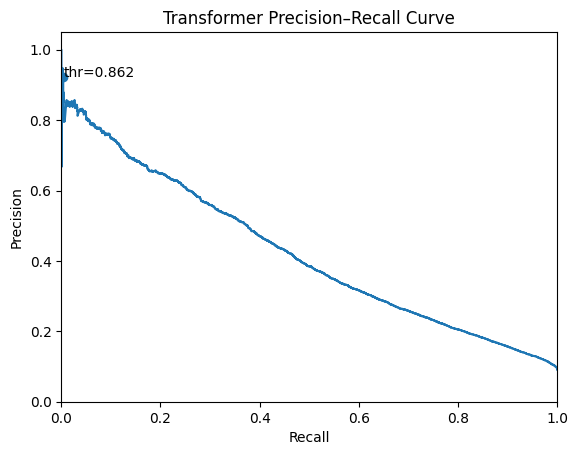

In [ ]:
import matplotlib.pyplot as plt

precision = out["precision"]
recall = out["recall"]
chosen = out["chosen_threshold"]

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Transformer Precision–Recall Curve")

# Mark chosen operating point if it exists
if chosen is not None:
    plt.scatter([chosen["recall"]], [chosen["precision"]])
    plt.annotate(
        f"thr={chosen['threshold']:.3f}",
        (chosen["recall"], chosen["precision"])
    )

plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.show()


In [45]:
for tp in [0.9, 0.8, 0.75, 0.7]:
    out = eval_auroc_pr_transformer(model=model,test_traces=test_traces,device=DEVICE,max_ctx=max_ctx,
    pad_id=pad_id,bos_id=bos_id,K=K,trigram_subset=True,num_neg=10,target_precision=tp)
    print(tp, out["chosen_threshold"])


0.9 {'threshold': 0.8618366718292236, 'precision': 0.9230769230769231, 'recall': 0.003961703532518983}
0.8 {'threshold': 0.5924429893493652, 'precision': 0.8, 'recall': 0.056784417299438755}
0.75 {'threshold': 0.45692628622055054, 'precision': 0.750920245398773, 'recall': 0.10102344007923407}
0.7 {'threshold': 0.37740224599838257, 'precision': 0.7002561912894961, 'recall': 0.13535820402773194}


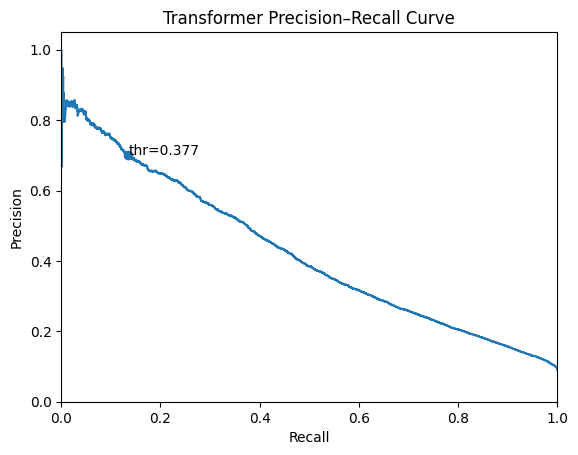

In [46]:
import matplotlib.pyplot as plt

precision = out["precision"]
recall = out["recall"]
chosen = out["chosen_threshold"]

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Transformer Precision–Recall Curve")

# Mark chosen operating point if it exists
if chosen is not None:
    plt.scatter([chosen["recall"]], [chosen["precision"]])
    plt.annotate(
        f"thr={chosen['threshold']:.3f}",
        (chosen["recall"], chosen["precision"])
    )

plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.show()


In [48]:
print(out["precision"])
print(out["recall"])
print(out["thresholds"])
len(out["precision"]), len(out["recall"]), len(out["thresholds"])

[0.09090909 0.09091046 0.09091182 ... 1.         1.         1.        ]
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 3.30141961e-04
 1.65070981e-04 0.00000000e+00]
[3.93101691e-05 4.78037655e-05 5.70559641e-05 ... 9.11430955e-01
 9.21103954e-01 9.26611483e-01]


(57005, 57005, 57004)

In [49]:
for tp in [0.6,0.5]:
    out = eval_auroc_pr_transformer(model=model,test_traces=test_traces,device=DEVICE,max_ctx=max_ctx,
    pad_id=pad_id,bos_id=bos_id,K=K,trigram_subset=True,num_neg=10,target_precision=tp)
    print(tp, out["chosen_threshold"])

0.6 {'threshold': 0.1903807371854782, 'precision': 0.6, 'recall': 0.25652030373060414}
0.5 {'threshold': 0.1030152216553688, 'precision': 0.5, 'recall': 0.37603169362826017}


In [50]:
print(out["precision"])
print(out["recall"])
print(out["thresholds"])

[0.09090909 0.09091046 0.09091182 ... 1.         1.         1.        ]
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 3.30141961e-04
 1.65070981e-04 0.00000000e+00]
[3.93101691e-05 4.78037655e-05 5.70559641e-05 ... 9.11430955e-01
 9.21103954e-01 9.26611483e-01]


In [51]:
np.savez_compressed("precision_recall_thresholds_transfomrer.npz",
    precision=out["precision"], recall=out["recall"], thresholds=out["thresholds"])

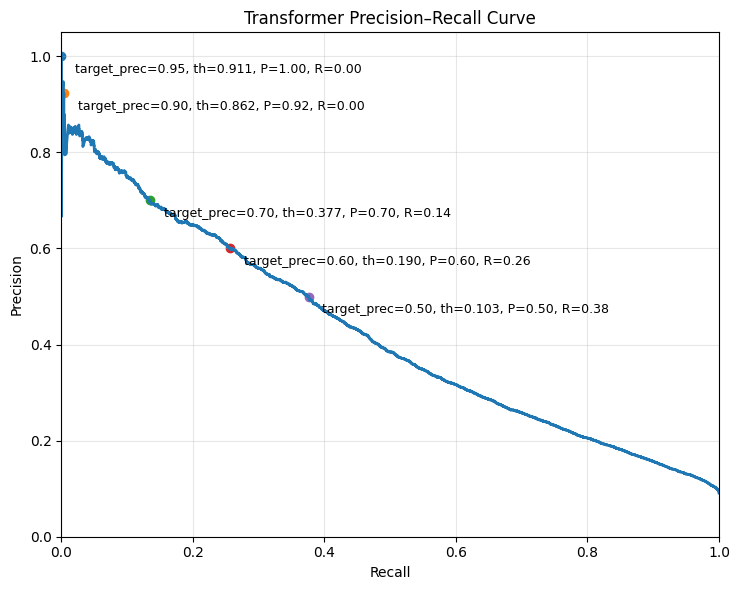

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Load PR arrays
npz_path = "precision_recall_thresholds_transfomrer.npz"  # adjust path if needed
d = np.load(npz_path)

P = d["precision"]     # precision array (len N+1)
R = d["recall"]        # recall array (len N+1)
T = d["thresholds"]    # thresholds array (len N)

# 2) Thresholds you want to annotate (from your sweep results)
reported = [
    ("target_prec=0.95", 0.9114309549331665),
    ("target_prec=0.90", 0.8618366718292236),
    ("target_prec=0.70", 0.37740224599838257),
    ("target_prec=0.60", 0.1903807371854782),
    ("target_prec=0.50", 0.1030152216553688),
]

def pr_at_threshold(th):
    """
    Find the closest threshold index in T and map it to PR point.
    Note: In sklearn's precision_recall_curve:
      threshold[i] corresponds to precision[i+1], recall[i+1]
    """
    j = int(np.argmin(np.abs(T - th)))
    return j, float(P[j+1]), float(R[j+1]), float(T[j])

# Build points list: (label, requested_th, closest_th, precision, recall, index)
points = []
for label, th in reported:
    j, p, r, t_closest = pr_at_threshold(th)
    points.append((label, th, t_closest, p, r, j))

# 3) Plot PR curve + annotate operating points (ONE LINE each)
plt.figure(figsize=(7.5, 6))
plt.plot(R, P, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Transformer Precision–Recall Curve")

for label, th_req, th_close, p, r, j in points:
    txt = f"{label}, th={th_close:.3f}, P={p:.2f}, R={r:.2f}"
    plt.scatter([r], [p])
    plt.annotate(
        txt,
        (r, p),
        textcoords="offset points",
        xytext=(10, -12),   # push slightly down so it doesn't hit the title
        ha="left",
        fontsize=9,
    )

plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### PR + AUROC for Trigram

In [40]:
clusters_tsv = "processed_data/clusters/screen_clusters_k110.tsv"

In [73]:
print(len(test_traces[0]))
print(len(test_traces[0][2]))
for k in range (len(test_traces)):
    if (len(test_traces[k][2]) == 1):
        print(len(test_traces[k][2]))

3
2


In [61]:
print(test_traces[2])
print(prob_next("trigram", test_traces[2][2], 2))

('air.com.readysquare.scsm', 'trace_0', [8, 23, 29])
0.014393282971894412


In [83]:
for k in range(1,len(test_traces)):
    _,_, seq = test_traces[k]
    if len(seq) <= 2:
        continue
    pr= prob_next("trigram", test_traces[k][2], 2)
    if (pr >0.4):
        print(pr)
        print(test_traces[k][2])
        

0.40940348616806455
[30, 28, 30, 5, 9, 15, 9, 5, 3, 10, 30, 15, 30, 15, 9, 39, 28]
0.40940348616806455
[30, 28, 30, 20, 30, 23, 30, 23, 20, 3, 30, 20, 30, 28, 20]


Built anomaly dataset for model=trigram
  normal examples   : 6058
  corrupted examples: 6058
  total             : 12116
  positive rate     : 0.5000
Average Precision (AP) ≈ 0.7466


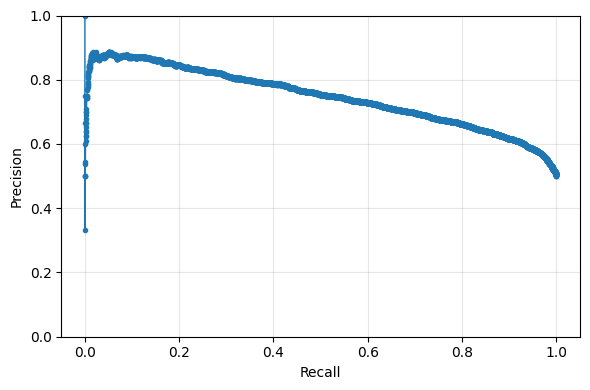

Saved: pr_curve_trigram.png
Top-50 alerts: threshold=5.2467 | Precision=0.8039 | Recall=0.0068
Top-100 alerts: threshold=5.0798 | Precision=0.8800 | Recall=0.0145
Top-200 alerts: threshold=4.9560 | Precision=0.8657 | Recall=0.0287


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
RNG_SEED = 42
NUM_CORRUPT_PER_EDGE = 1   # 1 corrupted example per normal edge
EPS = 1e-12

# Choose model for scoring: "unigram", "bigram", or "trigram"
MODEL_FOR_ANOMALY = "trigram"   # <-- recommended (strongest baseline)
LAMBDA_BACKOFF = 0.2            # use same as your recall experiments

rng = np.random.default_rng(RNG_SEED)

# -----------------------------
# Helper: get probability of a candidate next state
# -----------------------------
def prob_next(model_name, seq, t):
    """
    Returns P_model(next=seq[t] | history) for position t (t>=1 for bigram, t>=2 for trigram)
    seq[t] is the "next"
    """
    c = seq[t]

    if model_name == "unigram":
        return float(unigram_probs[c])

    elif model_name == "bigram":
        b = seq[t-1]
        return float(bigram_probs[b, c])

    elif model_name == "trigram":
        a = seq[t-2]
        b = seq[t-1]
        probs = score_next_probs(
            a, b,
            trigram_probs=trigram_probs,
            bigram_probs=bigram_probs,
            unigram_probs=unigram_probs,
            lambda_backoff=LAMBDA_BACKOFF
        )
        return float(probs[c])

    else:
        raise ValueError(f"Unknown model_name={model_name}")




# -----------------------------
# 1) Build anomaly dataset: normal edges + corrupted edges
# -----------------------------
def build_scores_labels_from_test_traces(test_traces, K, model_name="trigram",
                                        num_corrupt_per_edge=1,
                                        trigram_subset_only=True):
    """
    Creates arrays:
      - scores: -log P_model(c|history)
      - labels: 0 for normal, 1 for corrupted
    Corruption: replace the true next cluster with a random different cluster.
    """
    scores = []
    labels = []

    total_normal = 0
    total_corrupt = 0

    for _, _, seq in test_traces:
        # Determine start index based on model/history needs
        if model_name == "unigram":
            start = 2 if trigram_subset_only else 1  # to match context positions if desired
        elif model_name == "bigram":
            start = 2 if trigram_subset_only else 1
        elif model_name == "trigram":
            start = 2
        else:
            raise ValueError(model_name)

        if len(seq) <= start:
            continue

        for t in range(start, len(seq)):
            true_next = seq[t]

            # --- Normal example ---
            p = prob_next(model_name, seq, t)
            score = -np.log(p + EPS)
            scores.append(score)
            labels.append(0)
            total_normal += 1

            # --- Corrupted examples ---
            for _ in range(num_corrupt_per_edge):
                # sample a wrong next cluster
                wrong = rng.integers(0, K)
                while wrong == true_next:
                    wrong = rng.integers(0, K)

                # temporarily swap the next state for scoring
                original = seq[t]
                seq[t] = wrong
                p_wrong = prob_next(model_name, seq, t)
                seq[t] = original

                score_wrong = -np.log(p_wrong + EPS)
                scores.append(score_wrong)
                labels.append(1)
                total_corrupt += 1

    scores = np.array(scores, dtype=np.float64)
    labels = np.array(labels, dtype=np.int32)

    print(f"Built anomaly dataset for model={model_name}")
    print(f"  normal examples   : {total_normal}")
    print(f"  corrupted examples: {total_corrupt}")
    print(f"  total             : {len(labels)}")
    print(f"  positive rate     : {labels.mean():.4f}")
    return scores, labels

scores, labels = build_scores_labels_from_test_traces(
    test_traces=test_traces,
    K=K,
    model_name=MODEL_FOR_ANOMALY,
    num_corrupt_per_edge=NUM_CORRUPT_PER_EDGE,
    trigram_subset_only=True
)

# -----------------------------
# 2) Manual Precision–Recall curve + AP
# -----------------------------
def precision_recall_curve_manual(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]

    P = y_true.sum()
    if P == 0:
        raise ValueError("No positives; PR undefined.")

    tp = 0
    fp = 0

    precision = []
    recall = []
    thresholds = []

    prev_score = None
    for i in range(len(y_score)):
        s = y_score[i]
        if prev_score is None or s != prev_score:
            if (tp + fp) > 0:
                precision.append(tp / (tp + fp))
                recall.append(tp / P)
                thresholds.append(s)
            prev_score = s

        if y_true[i] == 1:
            tp += 1
        else:
            fp += 1

    precision.append(tp / (tp + fp))
    recall.append(tp / P)
    thresholds.append(y_score[-1])

    return np.array(precision), np.array(recall), np.array(thresholds)

def average_precision_trapz(precision, recall):
    order = np.argsort(recall)
    r = recall[order]
    p = precision[order]
    return np.trapz(p, r)

prec, rec, thr = precision_recall_curve_manual(labels, scores)
ap = average_precision_trapz(prec, rec)

print(f"Average Precision (AP) ≈ {ap:.4f}")

plt.figure(figsize=(6,4))
plt.plot(rec, prec, marker=".", linewidth=1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"pr_curve_{MODEL_FOR_ANOMALY}.png", dpi=300)
plt.show()

print(f"Saved: pr_curve_{MODEL_FOR_ANOMALY}.png")

# -----------------------------
# 3) Practical threshold: "top-N alerts" (global)
# -----------------------------
def precision_recall_at_topN(scores, labels, N):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)

    if N <= 0:
        raise ValueError("N must be positive.")
    N = min(N, len(scores))

    # threshold is Nth largest score
    t = np.sort(scores)[-N]
    pred = (scores >= t).astype(int)

    tp = ((pred == 1) & (labels == 1)).sum()
    fp = ((pred == 1) & (labels == 0)).sum()
    fn = ((pred == 0) & (labels == 1)).sum()

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    return t, precision, recall

for N in [50, 100, 200]:
    t, p, r = precision_recall_at_topN(scores, labels, N)
    print(f"Top-{N} alerts: threshold={t:.4f} | Precision={p:.4f} | Recall={r:.4f}")


In [86]:
CORRUPT_RATE = 0.01  # try 0.10, 0.05, 0.01
rng = np.random.default_rng(42)

def build_scores_labels_rare_anomalies(test_traces, K, model_name="trigram",
                                      corrupt_rate=0.05, trigram_subset_only=True):
    scores, labels = [], []
    total_normal = total_corrupt = 0

    for _, _, seq in test_traces:
        start = 2  # trigram positions only
        if len(seq) <= start:
            continue

        for t in range(start, len(seq)):
            true_next = seq[t]

            # normal
            p = prob_next(model_name, seq, t)
            scores.append(-np.log(p + 1e-12))
            labels.append(0)
            total_normal += 1

            # corrupt with probability = corrupt_rate
            if rng.random() < corrupt_rate:
                wrong = rng.integers(0, K)
                while wrong == true_next:
                    wrong = rng.integers(0, K)

                original = seq[t]
                seq[t] = wrong
                p_wrong = prob_next(model_name, seq, t)
                seq[t] = original

                scores.append(-np.log(p_wrong + 1e-12))
                labels.append(1)
                total_corrupt += 1

    scores = np.array(scores, dtype=np.float64)
    labels = np.array(labels, dtype=np.int32)

    print(f"Rare anomaly dataset (rate={corrupt_rate})")
    print(f"  normal   : {total_normal}")
    print(f"  corrupt  : {total_corrupt}")
    print(f"  positive rate: {labels.mean():.4f}")
    return scores, labels

scores_5, labels_5 = build_scores_labels_rare_anomalies(
    test_traces, K, model_name="trigram", corrupt_rate=CORRUPT_RATE
)


Rare anomaly dataset (rate=0.01)
  normal   : 6058
  corrupt  : 56
  positive rate: 0.0092


Rare anomaly dataset (rate=0.01)
  normal   : 6058
  corrupt  : 65
  positive rate: 0.0106


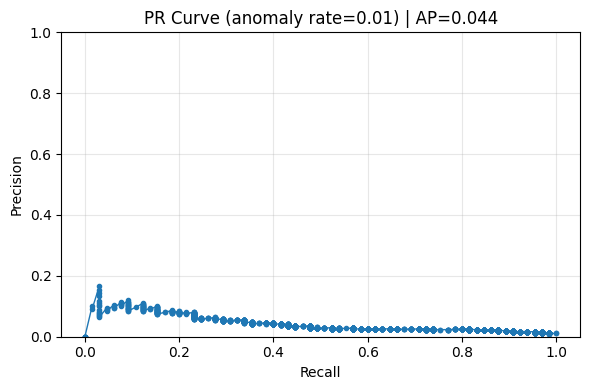

Rare anomaly dataset (rate=0.05)
  normal   : 6058
  corrupt  : 296
  positive rate: 0.0466


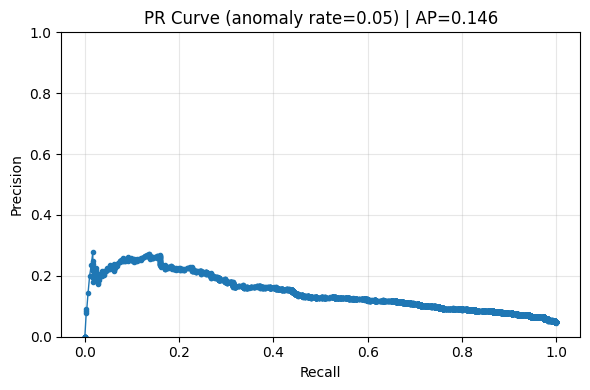

Rare anomaly dataset (rate=0.1)
  normal   : 6058
  corrupt  : 618
  positive rate: 0.0926


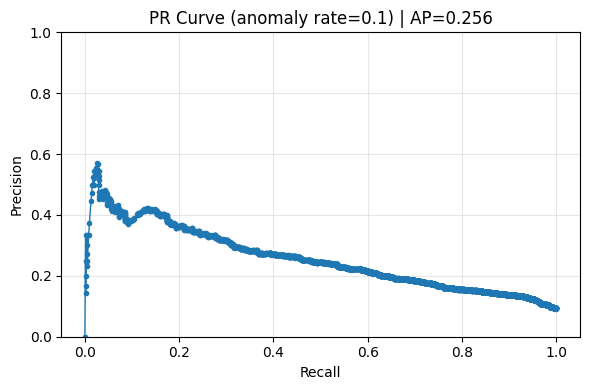

,rate,AP,TopN,threshold,precision,recall,num_pos,num_total
0,0.01,0.044060,5,5.576870,0.00,0.000000,65,6123
1,0.01,0.044060,10,5.357554,0.10,0.015385,65,6123
2,0.01,0.044060,20,5.016894,0.10,0.030769,65,6123
3,0.01,0.044060,50,4.778587,0.12,0.092308,65,6123
4,0.01,0.044060,100,4.601550,0.10,0.153846,65,6123
5,0.05,0.146449,5,5.576870,0.00,0.000000,296,6354
6,0.05,0.146449,10,5.354671,0.00,0.000000,296,6354
7,0.05,0.146449,20,5.052122,0.25,0.016892,296,6354
8,0.05,0.146449,50,4.828187,0.20,0.033784,296,6354
9,0.05,0.146449,100,4.648312,0.25,0.084459,296,6354


In [89]:
rates = [0.01, 0.05, 0.10]
topN_list = [5, 10, 20, 50, 100]

all_summary = []

for rate in rates:
    scores, labels = build_scores_labels_rare_anomalies(
        test_traces=test_traces,
        K=K,
        model_name="trigram",
        corrupt_rate=rate,      # now treated as probability
        trigram_subset_only=True
    )

    prec, rec, thr = precision_recall_curve_manual(labels, scores)
    ap = average_precision_trapz(prec, rec)

    # Plot PR curve
    plt.figure(figsize=(6,4))
    plt.plot(rec, prec, marker=".", linewidth=1)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.title(f"PR Curve (anomaly rate={rate}) | AP={ap:.3f}")
    plt.tight_layout()
    plt.savefig(f"pr_curve_rate_{rate}.png", dpi=300)
    plt.show()

    # Top-N alert metrics
    for N in topN_list:
        t, p_atN, r_atN = precision_recall_at_topN(scores, labels, N)
        all_summary.append({
            "rate": rate,
            "AP": ap,
            "TopN": N,
            "threshold": float(t),
            "precision": float(p_atN),
            "recall": float(r_atN),
            "num_pos": int(labels.sum()),
            "num_total": int(len(labels))
        })

# Convert to DataFrame for a clean table
import pandas as pd
summary_df = pd.DataFrame(all_summary)
summary_df


In [1]:
import numpy as np
from collections import defaultdict

def per_app_topN_metrics(scores, labels, app_ids, N):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    app_ids = np.asarray(app_ids)

    apps = np.unique(app_ids)
    per_app = []

    for a in apps:
        idx = np.where(app_ids == a)[0]
        if len(idx) == 0:
            continue

        s = scores[idx]
        y = labels[idx]

        # If no positives in this app, skip for recall; still can count precision if you want
        if y.sum() == 0:
            continue

        n = min(N, len(s))
        top_idx = np.argsort(-s)[:n]
        pred = np.zeros_like(y)
        pred[top_idx] = 1

        tp = ((pred == 1) & (y == 1)).sum()
        fp = ((pred == 1) & (y == 0)).sum()
        fn = ((pred == 0) & (y == 1)).sum()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)

        per_app.append((precision, recall, int(y.sum()), len(y)))

    if not per_app:
        return None

    precs = np.array([p for p, r, pos, m in per_app])
    recs  = np.array([r for p, r, pos, m in per_app])

    return {
        "N": N,
        "num_apps": len(per_app),
        "precision_mean": float(precs.mean()),
        "precision_median": float(np.median(precs)),
        "recall_mean": float(recs.mean()),
        "recall_median": float(np.median(recs)),
    }

# Example usage:
# for N in [1,3,5,10]:
#     print(per_app_topN_metrics(scores, labels, app_ids, N))


In [2]:
for N in [1,3,5,10]:
     print(per_app_topN_metrics(scores, labels, app_ids, N))


NameError: name 'scores' is not defined

after getting results from 13_4

after changed ../../dataset/traces/filtered_traces/com.cerminara.yazzy/trace_2/screenshots/1010.jpg
after changed ../../dataset/traces/filtered_traces/com.cerminara.yazzy/trace_2/screenshots/1136.jpg
after changed ../../dataset/traces/filtered_traces/air.com.golfchannel.gcliveextra/trace_0/screenshots/89.jpg


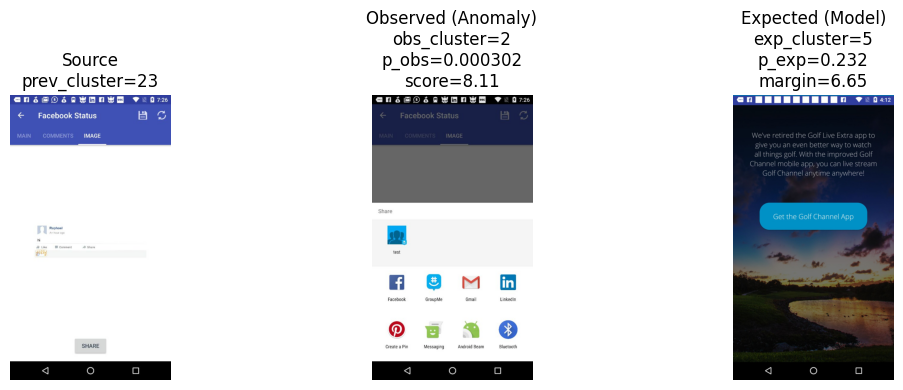

after changed ../../dataset/traces/filtered_traces/com.kayak.android/trace_1/screenshots/861.jpg
after changed ../../dataset/traces/filtered_traces/com.kayak.android/trace_1/screenshots/1588.jpg
after changed ../../dataset/traces/filtered_traces/Pedcall.Calculator/trace_0/screenshots/357.jpg


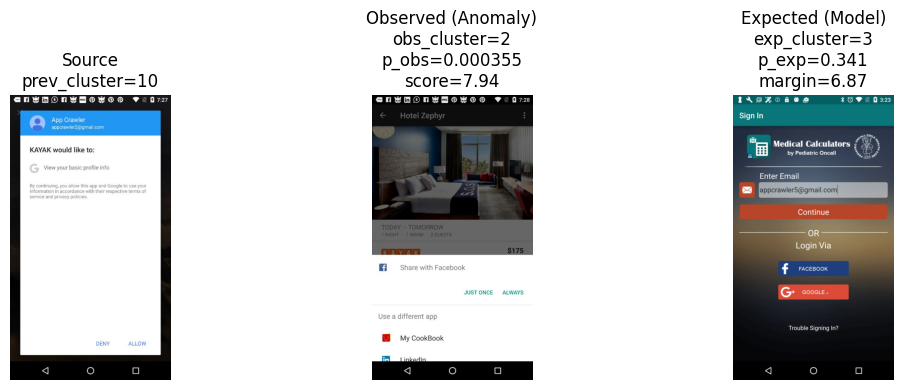

after changed ../../dataset/traces/filtered_traces/com.doapps.android.mln.MLN_d41b5422b44a34d123006225fd1d3484/trace_0/screenshots/341.jpg
after changed ../../dataset/traces/filtered_traces/com.doapps.android.mln.MLN_d41b5422b44a34d123006225fd1d3484/trace_0/screenshots/369.jpg
after changed ../../dataset/traces/filtered_traces/air.com.nbcuni.com.nbcsports.liveextra/trace_0/screenshots/42.jpg


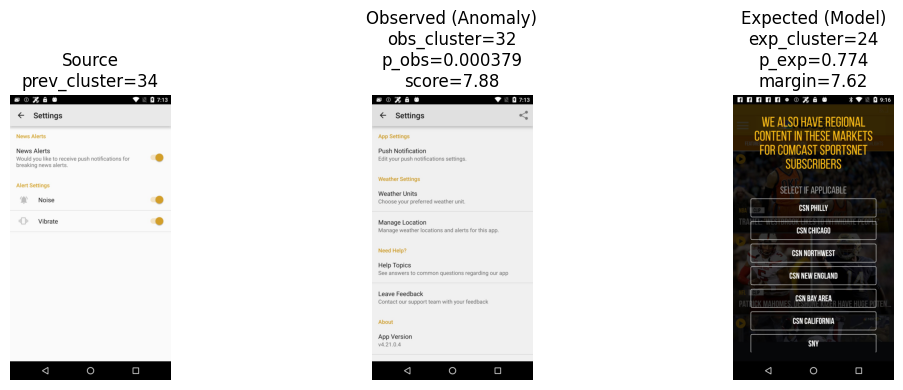

after changed ../../dataset/traces/filtered_traces/com.QuranReading.qurannow/trace_0/screenshots/483.jpg
after changed ../../dataset/traces/filtered_traces/com.QuranReading.qurannow/trace_0/screenshots/559.jpg
after changed ../../dataset/traces/filtered_traces/HinKhoj.Dictionary/trace_1/screenshots/1013.jpg


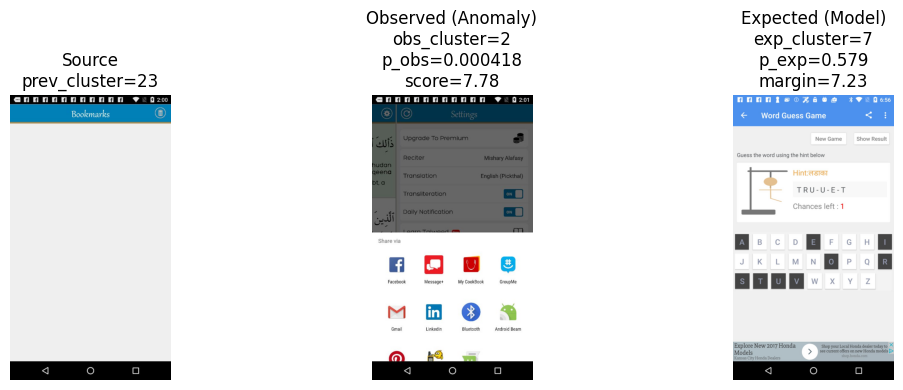

after changed ../../dataset/traces/filtered_traces/com.mobisystems.msdict.embedded.wireless.webster.collegedictionary/trace_0/screenshots/573.jpg
after changed ../../dataset/traces/filtered_traces/com.mobisystems.msdict.embedded.wireless.webster.collegedictionary/trace_0/screenshots/577.jpg
after changed ../../dataset/traces/filtered_traces/Pedcall.Calculator/trace_0/screenshots/1044.jpg


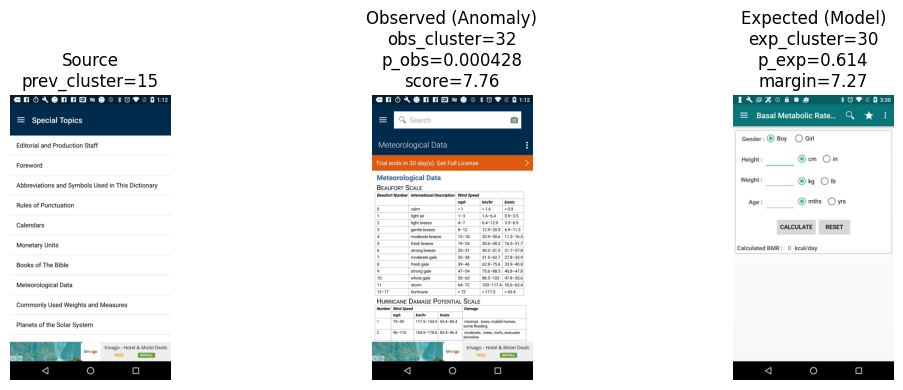

after changed ../../dataset/traces/filtered_traces/com.hobbylobbystores.android/trace_0/screenshots/2039.jpg
after changed ../../dataset/traces/filtered_traces/com.hobbylobbystores.android/trace_0/screenshots/2140.jpg
after changed ../../dataset/traces/filtered_traces/Pedcall.Calculator/trace_0/screenshots/1044.jpg


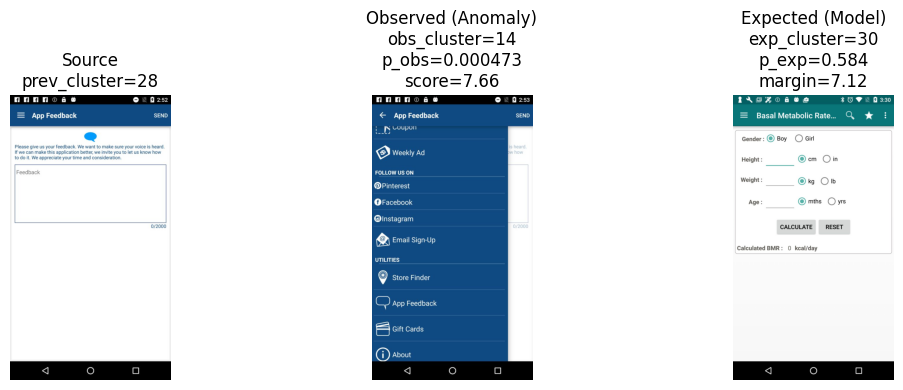

after changed ../../dataset/traces/filtered_traces/com.movinapp.english.flashcards/trace_1/screenshots/147.jpg
after changed ../../dataset/traces/filtered_traces/com.movinapp.english.flashcards/trace_1/screenshots/165.jpg
after changed ../../dataset/traces/filtered_traces/B4A.BigFivePersonalityTest/trace_0/screenshots/221.jpg


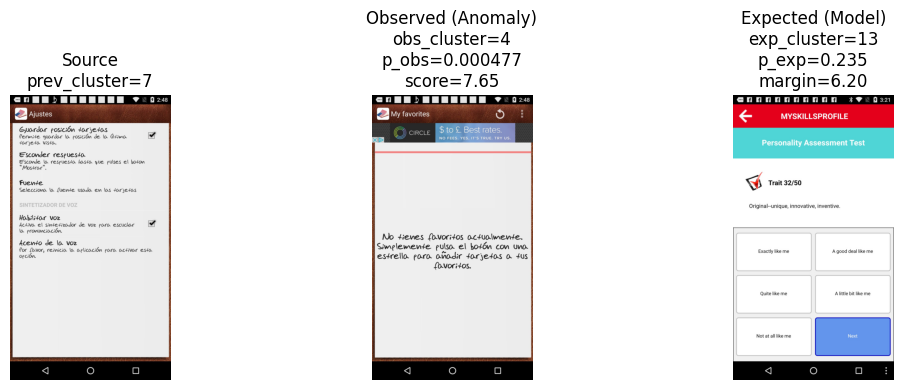

after changed ../../dataset/traces/filtered_traces/jokes.santabanta.com/trace_0/screenshots/597.jpg
after changed ../../dataset/traces/filtered_traces/jokes.santabanta.com/trace_0/screenshots/842.jpg
after changed ../../dataset/traces/filtered_traces/air.com.interactech.moovz/trace_0/screenshots/385.jpg


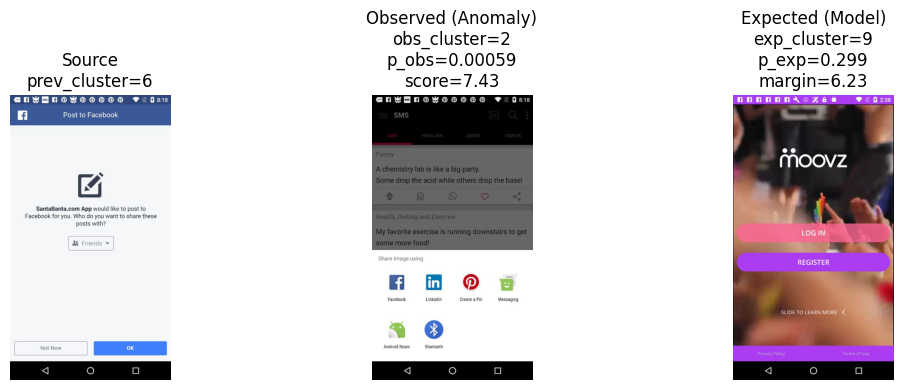

after changed ../../dataset/traces/filtered_traces/com.opteum.opteumTaxi/trace_0/screenshots/107.jpg
after changed ../../dataset/traces/filtered_traces/com.opteum.opteumTaxi/trace_0/screenshots/118.jpg
after changed ../../dataset/traces/filtered_traces/Gecko.Droid.PhysicsHelper/trace_0/screenshots/194.jpg


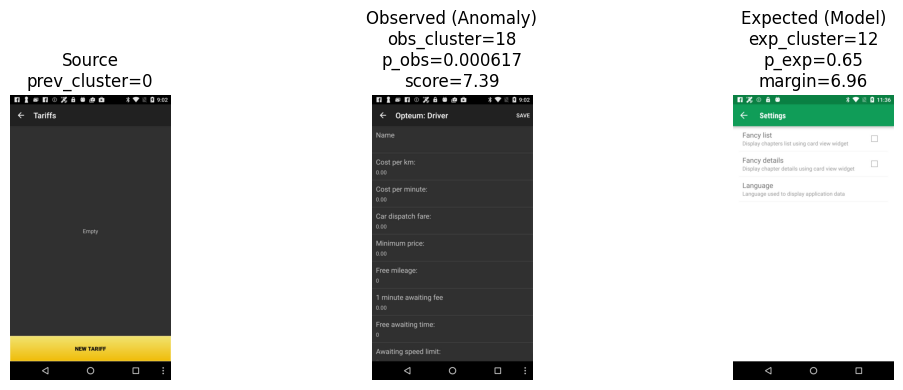

after changed ../../dataset/traces/filtered_traces/com.mapmyride.android2/trace_1/screenshots/945.jpg
after changed ../../dataset/traces/filtered_traces/com.mapmyride.android2/trace_1/screenshots/1044.jpg
after changed ../../dataset/traces/filtered_traces/DOCECG2.doctor/trace_0/screenshots/58.jpg


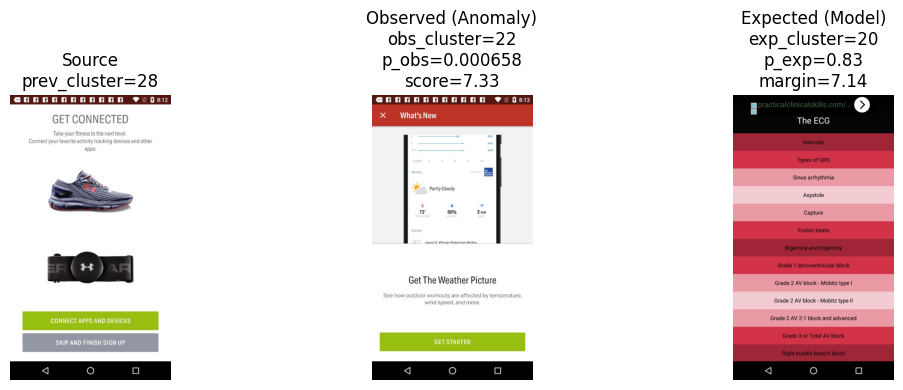

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def show_anomaly_row(row):
    imgs = [row["prev_img"], row["obs_img"], row["exp_img"]]
    titles = [
        f"Source\nprev_cluster={row['prev_cluster']}",
        f"Observed (Anomaly)\nobs_cluster={row['obs_cluster']}\np_obs={row['p_obs']:.3g}\nscore={row['anomaly_score']:.2f}",
        f"Expected (Model)\nexp_cluster={row['exp_cluster']}\np_exp={row['p_exp']:.3g}\nmargin={row['margin_log']:.2f}",
    ]

    plt.figure(figsize=(12,4))
    for i, (path, title) in enumerate(zip(imgs, titles), 1):
        ax = plt.subplot(1,3,i)
        ax.set_title(title)
        ax.axis("off")
        try:
            #path = path.replace("screens/","../../dataset/traces/filtered_traces")
            
            print("after changed",path)
            ax.imshow(Image.open(path).convert("RGB"))
        except Exception as e:
            ax.text(0.5, 0.5, f"Failed to load:\n{path}\n\n{e}", ha="center", va="center")
    plt.tight_layout()
    plt.show()

df = pd.read_csv("outputs/anomalies_tf_k40_top200.tsv", sep="\t")
for i in range(10):
    show_anomaly_row(df.iloc[i])


all exp choices: exp_choice
same_app    186
global       14
Name: count, dtype: int64
After filters: 141
after changed ../../dataset/traces/filtered_traces/com.kayak.android/trace_1/screenshots/861.jpg
after changed ../../dataset/traces/filtered_traces/com.kayak.android/trace_1/screenshots/1588.jpg
after changed ../../dataset/traces/filtered_traces/com.kayak.android/trace_1/screenshots/560.jpg


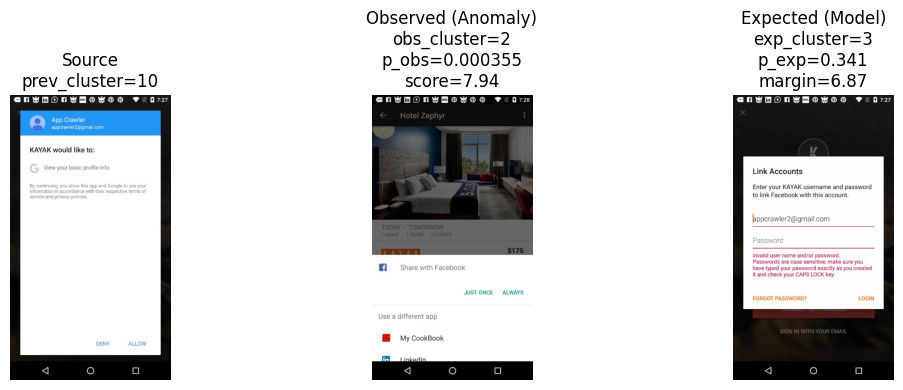

after changed ../../dataset/traces/filtered_traces/com.doapps.android.mln.MLN_d41b5422b44a34d123006225fd1d3484/trace_0/screenshots/341.jpg
after changed ../../dataset/traces/filtered_traces/com.doapps.android.mln.MLN_d41b5422b44a34d123006225fd1d3484/trace_0/screenshots/369.jpg
after changed ../../dataset/traces/filtered_traces/com.doapps.android.mln.MLN_d41b5422b44a34d123006225fd1d3484/trace_0/screenshots/114.jpg


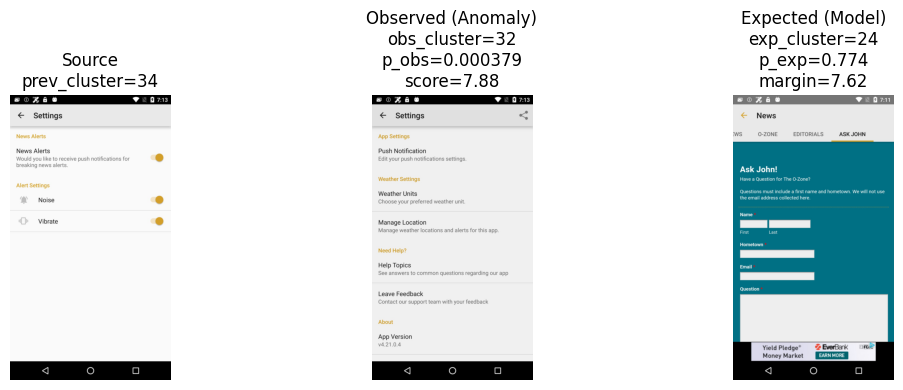

after changed ../../dataset/traces/filtered_traces/com.QuranReading.qurannow/trace_0/screenshots/483.jpg
after changed ../../dataset/traces/filtered_traces/com.QuranReading.qurannow/trace_0/screenshots/559.jpg
after changed ../../dataset/traces/filtered_traces/com.QuranReading.qurannow/trace_0/screenshots/146.jpg


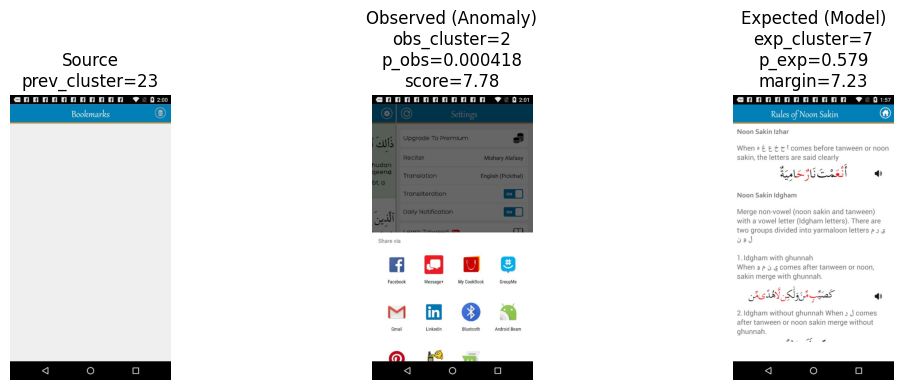

after changed ../../dataset/traces/filtered_traces/com.mobisystems.msdict.embedded.wireless.webster.collegedictionary/trace_0/screenshots/573.jpg
after changed ../../dataset/traces/filtered_traces/com.mobisystems.msdict.embedded.wireless.webster.collegedictionary/trace_0/screenshots/577.jpg
after changed ../../dataset/traces/filtered_traces/com.mobisystems.msdict.embedded.wireless.webster.collegedictionary/trace_0/screenshots/192.jpg


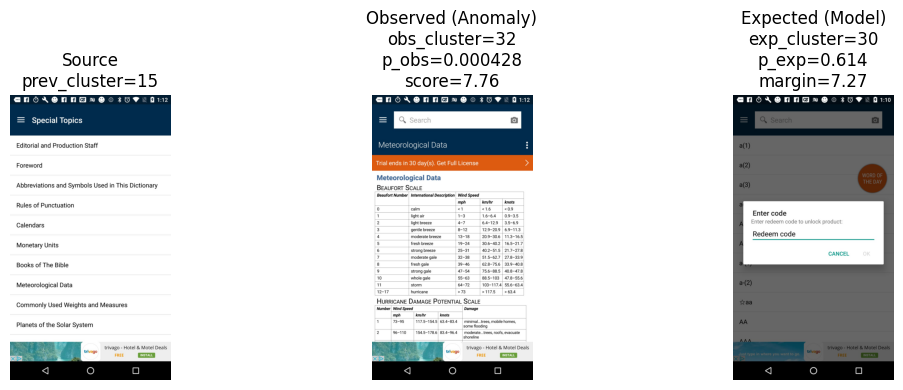

after changed ../../dataset/traces/filtered_traces/com.hobbylobbystores.android/trace_0/screenshots/2039.jpg
after changed ../../dataset/traces/filtered_traces/com.hobbylobbystores.android/trace_0/screenshots/2140.jpg
after changed ../../dataset/traces/filtered_traces/com.hobbylobbystores.android/trace_0/screenshots/1168.jpg


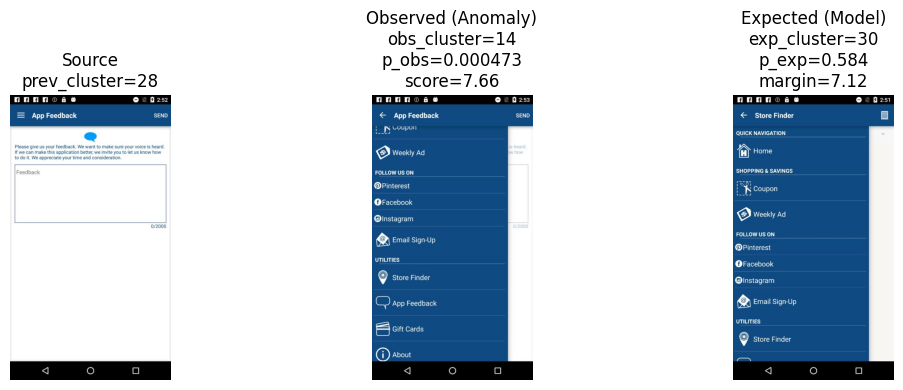

after changed ../../dataset/traces/filtered_traces/com.opteum.opteumTaxi/trace_0/screenshots/107.jpg
after changed ../../dataset/traces/filtered_traces/com.opteum.opteumTaxi/trace_0/screenshots/118.jpg
after changed ../../dataset/traces/filtered_traces/com.opteum.opteumTaxi/trace_0/screenshots/34.jpg


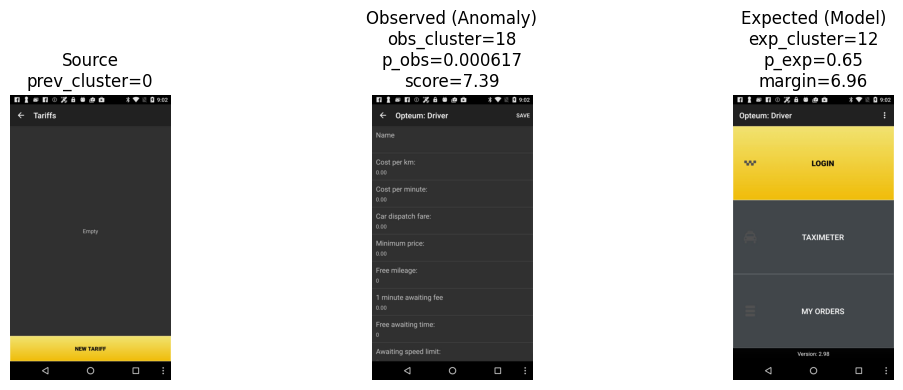

after changed ../../dataset/traces/filtered_traces/com.mapmyride.android2/trace_1/screenshots/945.jpg
after changed ../../dataset/traces/filtered_traces/com.mapmyride.android2/trace_1/screenshots/1044.jpg
after changed ../../dataset/traces/filtered_traces/com.mapmyride.android2/trace_0/screenshots/3.jpg


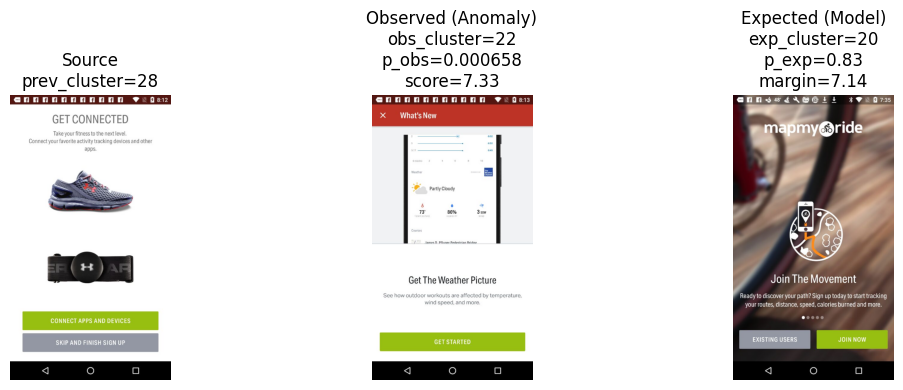

after changed ../../dataset/traces/filtered_traces/com.mapmywalk.android2/trace_0/screenshots/1488.jpg
after changed ../../dataset/traces/filtered_traces/com.mapmywalk.android2/trace_0/screenshots/1586.jpg
after changed ../../dataset/traces/filtered_traces/com.mapmywalk.android2/trace_0/screenshots/1416.jpg


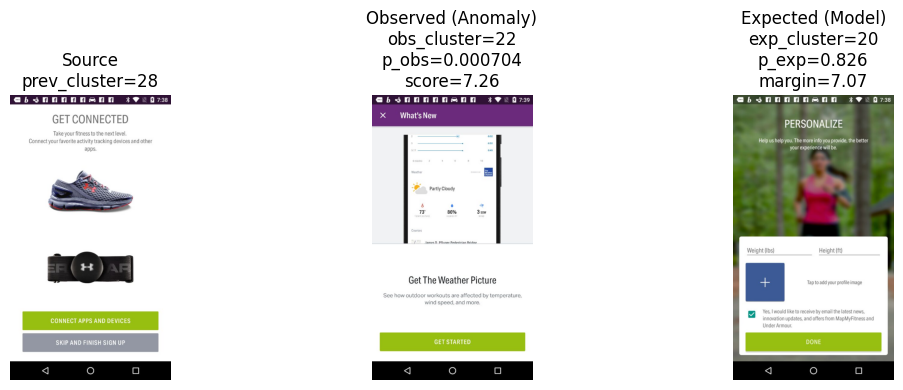

after changed ../../dataset/traces/filtered_traces/com.answers.android/trace_0/screenshots/480.jpg
after changed ../../dataset/traces/filtered_traces/com.answers.android/trace_0/screenshots/511.jpg
after changed ../../dataset/traces/filtered_traces/com.answers.android/trace_0/screenshots/28.jpg


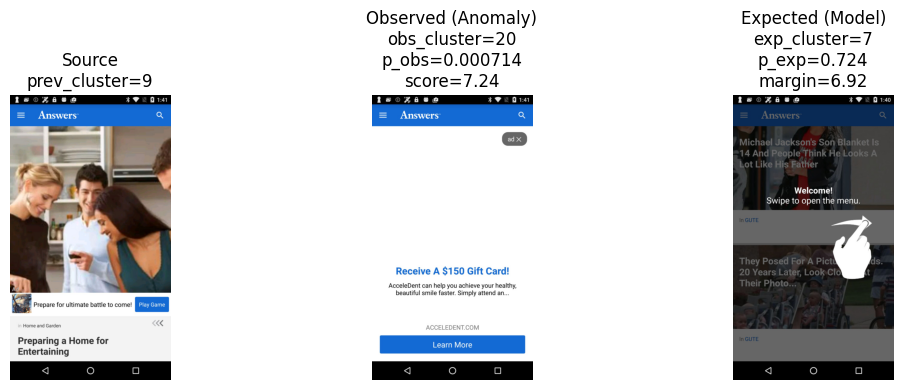

after changed ../../dataset/traces/filtered_traces/com.hungryhouse/trace_0/screenshots/1203.jpg
after changed ../../dataset/traces/filtered_traces/com.hungryhouse/trace_0/screenshots/1226.jpg
after changed ../../dataset/traces/filtered_traces/com.hungryhouse/trace_0/screenshots/1.jpg


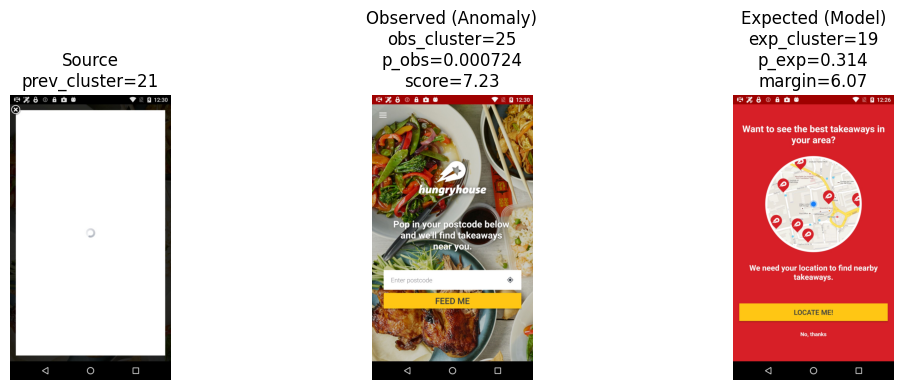

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import re

def show_anomaly_row(row):
    imgs = [row["prev_img"], row["obs_img"], row["exp_img"]]
    titles = [
        f"Source\nprev_cluster={row['prev_cluster']}",
        f"Observed (Anomaly)\nobs_cluster={row['obs_cluster']}\np_obs={row['p_obs']:.3g}\nscore={row['anomaly_score']:.2f}",
        f"Expected (Model)\nexp_cluster={row['exp_cluster']}\np_exp={row['p_exp']:.3g}\nmargin={row['margin_log']:.2f}",
    ]

    plt.figure(figsize=(12,4))
    for i, (path, title) in enumerate(zip(imgs, titles), 1):
        ax = plt.subplot(1,3,i)
        ax.set_title(title)
        ax.axis("off")
        try:
            #path = re.sub(r'/(trace_\d+)/(\d+)\.png', r'/\1/screenshots/\2.jpg', path)
            #path = path.replace("screens/","../../dataset/traces/filtered_traces/")
           
            print("after changed",path)
            ax.imshow(Image.open(path).convert("RGB"))
        except Exception as e:
            ax.text(0.5, 0.5, f"Failed to load:\n{path}\n\n{e}", ha="center", va="center")
    plt.tight_layout()
    plt.show()

df = pd.read_csv("outputs/anomalies_tf_k40_top200.tsv", sep="\t")


print("all exp choices:",df["exp_choice"].value_counts())

# --- Paper-figure curation filters (apply here) ---
df = df[
    (df["p_obs"] < 0.01) &
    (df["p_exp"] > 0.3) &
    (df["margin_log"] > 4.0)
].copy()

# Optional: avoid cross-app "expected" screens for figure clarity
if "exp_rep_app_id" in df.columns:
    df = df[df["app_id"] == df["exp_rep_app_id"]].copy()

df = df.sort_values(["anomaly_score", "margin_log"], ascending=[False, False]).reset_index(drop=True)

print("After filters:", len(df))

# Render top N after filtering
for i in range(min(10, len(df))):
    show_anomaly_row(df.iloc[i])
